In [ ]:
# importing required libraries

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# uploading dataset (CSV file)

from google.colab import files
uploaded=files.upload()

Saving Housing.csv to Housing.csv


## **Task 1 - Data Loading and Exploration**

In [60]:
# loading CSV file using pandas
data=pd.read_csv('Housing.csv')

In [ ]:
# displaying first 10 rows
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
# checking no of rows and columns

r,c=data.shape
print(f"Rows: {r} Columns: {c}")

Rows: 545 Columns: 13


In [61]:
# identifying the target and feature columns

target = 'price'
features = [col for col in data.columns if col != target]

print("Target Column:")
print(target)

print("\nFeature Columns:")
print(features)

Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [ ]:
# checking missing values
data.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## **Task 2 - Data Cleaning**

In [ ]:
# removing duplicate rows (if any)
data=data.drop_duplicates()

In [ ]:
# checking missing values again
data.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
# converting categorical data to numeric form for prediction
categ_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

data = pd.get_dummies(data,columns=categ_cols,drop_first=True,dtype=int)
data.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


## **Task 3 - Model Building**

In [ ]:
# preparing the data
x = data.drop('price', axis=1)
y = data['price']

In [ ]:
# splitting data into testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# building & training linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# making predictions for house price
pred = model.predict(X_test)

In [ ]:
# evaluating predictions using MAE, RMSE, R2 score
mae_lr = mean_absolute_error(y_test,pred)
rmse_lr = np.sqrt(mean_squared_error(y_test,pred))
r2_lr = r2_score(y_test,pred)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2: 0.6529242642153184


In [ ]:
# building & training random forest model
model_rf = RandomForestRegressor(n_estimators=100,random_state=42)

model_rf.fit(X_train, y_train)

# making prediction for house prices
pred_rf = model_rf.predict(X_test)

In [ ]:
# evaluating predictions using MAE, RMSE, R2 score
mae_rf = mean_absolute_error(y_test,pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test,pred_rf))

r2_rf = r2_score(y_test,pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


In [ ]:
# comparing both models
comparison = pd.DataFrame({'Model': ['Linear Regression','Random Forest'],
                           'MAE': [mae_lr, mae_rf],
                           'RMSE': [rmse_lr, rmse_rf],
                           'R2': [r2_lr, r2_rf]})

print(comparison)

               Model           MAE          RMSE        R2
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


## **Task 4 - Visualization**

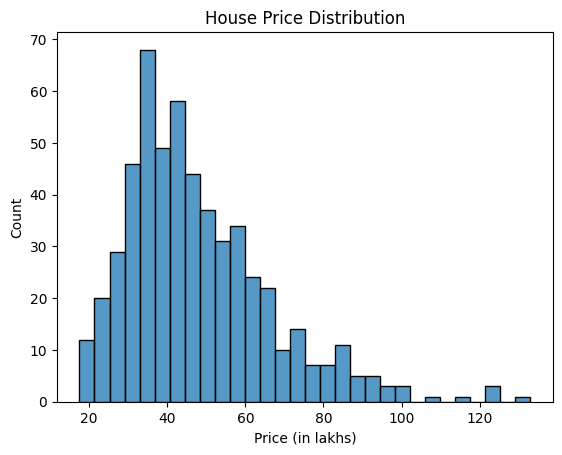

In [ ]:
# chart 1: histogram showing the distribution of house prices

sns.histplot(data['price']/100000, bins=30)
plt.title('House Price Distribution')
plt.savefig('price_distribution.png')
plt.xlabel("Price (in lakhs)")
plt.show()

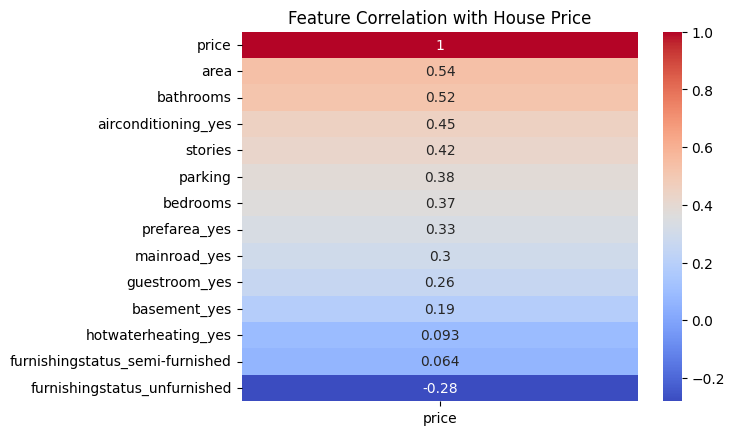

In [ ]:
# chart 2: correlation heatmap showing which features relate most strongly to price

price = data.corr()['price'].sort_values(ascending=False)

sns.heatmap(price.to_frame(),annot=True,cmap='coolwarm')

plt.title('Feature Correlation with House Price')
plt.savefig('correlation_heatmap.png')
plt.show()

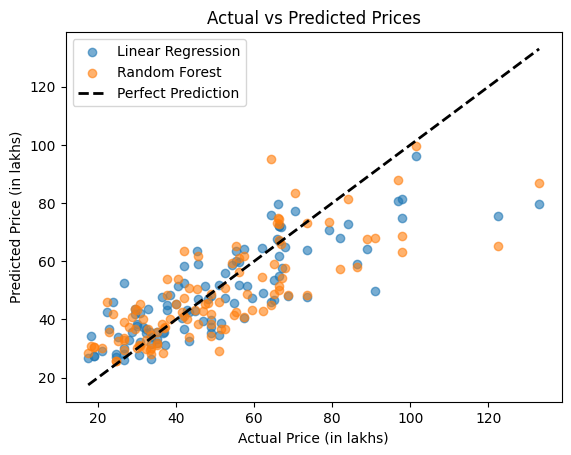

In [ ]:
# chart 3: scatter plot for actual vs predicted prices of both models

plt.scatter(y_test/100000,pred/100000,alpha=0.6,label='Linear Regression')

plt.scatter(y_test/100000,pred_rf/100000,alpha=0.6,label='Random Forest')

# perfect prediction line
plt.plot([y_test.min()/100000, y_test.max()/100000],[y_test.min()/100000, y_test.max()/100000],'k--',linewidth=2,label='Perfect Prediction')

plt.xlabel("Actual Price (in lakhs)")
plt.ylabel("Predicted Price (in lakhs)")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.savefig("model_prediction_comparison.png")
plt.show()

## **Task 5 - Insights and Summary**

The analysis showed that house area, number of bathrooms, and air conditioning were the most important factors affecting house prices. Among the two models tested, Linear Regression performed better explaining about 65% of the variation in house prices. The model's predictions differed from actual prices by approximately ₹9.7 lakh on average. An interesting finding was that Linear Regression outperformed Random Forest, suggesting that the relationship between house features and prices is fairly linear.
Based on these results, real estate businesses should focus on larger properties and key amenities such as bathrooms and air conditioning when priacing and marketing houses.